# Лабораторная работа 1. Введение в PyTorch

## Библиотека PyTorch

### Установка

Библиотека `PyTorch` используется для обучения нейронных сетей. Чтобы установить библиотеку локально воспользуйтесь руководством, доступном по ссылке https://pytorch.org/get-started/locally.

**(!) В среде colab библиотека** `PyTorch` **является уже предустановленной.**

Импорт библиотеки происходит обычным образом, а вывод установленной версии `PyTorch` можно сделать так
``` python
import torch
torch.__version__
```

В библиотеке `PyTorch` есть поддержка вычислений на `GPU`. В `colab` можно подключить видеокарту, для этого надо в меню `Runtime` перейти в настройки `Change runtime type` и выбрать `T4 GPU` (бесплатно доступная видеокарта). При этом произойдёт подключение к новой сессии.

Чтобы посмотреть полезную информацию о видеокарте, можно воспользоваться утилитой `nvidia-smi`, для этого в ячейке colab можно ввести команду:
```
!nvidia-smi
```

Также можно посмотреть дополнительную информацию о системе:
```python
print('Python VERSION:', sys.version)
print('\npyTorch VERSION:', torch.__version__)
print('\nCUDNN VERSION:', torch.backends.cudnn.version())
print('\nNumber CUDA Devices:', torch.cuda.device_count())
print('Current cuda device:', torch.cuda.current_device())
print('Cuda device name: ', torch.cuda.get_device_name(0))
```
Вывод `CUDA VERSION`
```
!nvcc --version
```


А проверить доступность видеокарты через библиотеку `PyTorch` можно так:
```python
torch.cuda.is_available()
```

**(!) Для выполнения текущей лабораторной работы видеокарта НЕ нужна.**

### Тензоры

*Тензор* в `PyTorch` – многомерный массив данных. Тензор может быть 0-мерным (скаляр), 1-мерным (вектор), 2-мерным (матрица) или размерностью больше двух.  
Тензоры используются для представления входных и выходных данных, а также параметров моделей.

Тензоры могут быть инициализированы несколькими способами.
1. На основе данных:
```python
data = [[1, 2],[3, 4]]
data_tensor = torch.tensor(data)
```
2. На основе `NumPy`-массива:
```python
import numpy as np
np_array = np.array(data)
np_tensor = torch.from_numpy(np_array)
```
3. На основе случайных значений или констант:
```python
shape = (2,3)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)
```
Тензоры имеют разные атрибуты, например:
```python
tensor = torch.rand(3, 4)
print(f'Shape of tensor: {tensor.shape}')
print(f'Datatype of tensor: {tensor.dtype}')
print(f'Device tensor is stored on the following device: {tensor.device}')
```

По умолчанию тензоры создаются на CPU. Для перемещения их на GPU нужно вызвать метод `.to()`:
```python
print(f'Tensor is stored on: {tensor.device}')
if torch.cuda.is_available():
    tensor = tensor.to('cuda')
print(f'Tensor is stored on: {tensor.device}')
```
Над тензорами можно совершать различные операции.
Индексирование и срезы (slicing):
```python
tensor = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print(f'Initial tensor:\n{tensor}\n')
print(f'First row: {tensor[0]}\n')
print(f'First column: {tensor[:, 0]}\n')
print(f'Last column: {tensor[..., -1]}\n')
tensor[:,1] = 0
print(tensor)
```
Конкатенация:
```python
concat_tensor = torch.cat([tensor, tensor, tensor], dim=1)
print(concat_tensor)
```

Арифметические операции:
```python
shape = (3, 3)
tensor1 = torch.ones(shape)
tensor2 = torch.ones(shape)
tensor_sum = tensor1 + tensor2
print(f'tensor1 + tensor2 = \n{tensor_sum}\n')
tensor_mul1 = tensor1 @ tensor2
print(f'tensor1 @ tensor2 = \n{tensor_mul1}\n')
tensor_mul2 = torch.matmul(tensor1, tensor2)
print(f'torch.matmul(tensor1, tensor2) = \n{tensor_mul2}\n')
tensor_mul3 = tensor1 * tensor2
print(f'tensor1 * tensor2 = \n{tensor_mul3}\n')
```

Более подробное руководство доступно по ссылке - https://docs.pytorch.org/tutorials/beginner/introyt/tensors_deeper_tutorial.html

### Autograd

Для настройки весов в нейронных сетях используется *алгоритм обратного распространения ошибки* (back propagation). В этом алгоритме веса изменяются в зависимости от градиента функции ошибки.  
В PyTorch модуль `torch.autograd` отвечает за автоматическое дифференцирование на вычислительном графе.

Рассмотрим сигмоидальную функцию и её производную:
$$\sigma(u)=\frac{1}{1+e^{-u}}$$
  
$$\sigma'(u)=\frac{e^{-u}}{(1+e^{-u})^2}=\frac{1}{(1+e^{-u})}\frac{e^{-u}}{(1+e^{-u})}=\frac{1}{(1+e^{-u})}\frac{(1+e^{-u})-1}{(1+e^{-u})}=\sigma(u)(1-\sigma(u))$$

Зададим эти функции в PyTorch и нарисуем их графики:
```python
def sigmoid(u):
    return 1 / (1 + torch.exp(-u))

def sigmoid_deriv(u):
    return sigmoid(u) * (1 - sigmoid(u))
```

Можно построить график функции и её производной:
```python
import matplotlib.pyplot as plt
x = torch.tensor(np.linspace(-5, 5, 100))
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position(('data', 0))
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, sigmoid_deriv(x), label='sigmoid_deriv')
ax.legend()
plt.show()
```

Зададим точку, в которой хотим найти градиент (параметр requires_grad=True) для функции:
```python
u = torch.tensor(0.0, requires_grad=True)
```

Вычислим значение функции в заданной точке:
```python
s = sigmoid(u)
```

В атрибуте `grad_fn` хранится ссылка на функцию, которая была использована для вычисления тензора.
```python
print(f'u.grad_fn: {u.grad_fn}\n')
print(f's.grad_fn: {s.grad_fn}\n')
a = u + u
print(f'(u+u).grad_fn: {a.grad_fn}\n')
a = u - u
print(f'(u-u).grad_fn: {a.grad_fn}\n')
a = u * u
print(f'(u*u).grad_fn: {a.grad_fn}\n')
a = u / u
print(f'(u/u).grad_fn: {a.grad_fn}\n')
a = 1 / u
print(f'(1/u).grad_fn: {a.grad_fn}\n')
a = torch.mean(u)
print(f'mean(u).grad_fn: {a.grad_fn}')
```
Для вычисления градиента необходимо вызвать метод `.backward()`:
```python
s.backward()
```

Значение градиента после вызова `.backward()` хранится в атрибуте `grad`:
```python
u.grad
```

(!) Обратите внимание, что повторный вызов метода .backward() невозможен.

Для того, чтобы повторно вызывать метод `backward`, следует указать при его вызове параметр `retain_graph=True`. Но в этом случае значение градиента будет накапливаться:
```python
a = torch.tensor(1.0, requires_grad=True)
b = a * a
b.backward(retain_graph=True)
print(f'a.grad = {a.grad}')
b.backward(retain_graph=True)
print(f'a.grad = {a.grad}')
b.backward()
print(f'a.grad = {a.grad}')
```

При необходимости градиенты можно обнулить:
```python
u.grad.data.zero_()
```


## Задание 1
Как соотносятся значения производной функции `sigmoid()` (написанную выше) в точках `points=[-1.0, 0.0, 1.0, 2.5]`, вычисленные через автоматическое дифференцирование библиотеки `PyTorch` и вычисленные через функцию `sigmoid_deriv` (написанную выше)?  
Ответьте письмено на вопросы:
- От чего вызывается метод .backward()?
- Где хранятся значения производных в точках?

In [ ]:
#ВАШ КОД И ОТВЕТ

## Задание 2
Используя модуль автоматического дифференицирования `PyTorch`, вычислите в точках из списка `points`, сформированного из диапазона `[-2; 2]` с шагом 0.2, значения производной функции
$$y(x)=sin(x^2)+2x.$$
Сравните с результатами вычисленными "вручную". Постройте графики функции и её производной в заданных точках.

**Для справки**:  
Формировать список `points` можно следующим образом:
```python
[i/10 for i in range(-20,20,2)]
```

При построении графиков потребуется преобразовать тензор в массив NumPy, для этого следует использовать методы .detach() и .numpy(). Например:
```python
x.detach().numpy()
```

In [ ]:
#ВАШ КОД И ОТВЕТ

## Построение нейронных сетей

Импорт модуля для работы с неронными сетями в библиотеке `PyTorch`:
```python
import torch.nn as nn
```
Для создания линейного слоя используется `nn.Linear(H_in, H_out)`. Входом линейного слоя будет матрица размерностью `(N, *, H_in)` и выходом будет матрица размерностью `(N, *, H_out)`. Символ `*` означает, что между ними может быть произвольное количество измерений.

Линейный уровень выполняет преобразование
$$Ax+b,$$
где `A` и `b` инициализируются случайным образом. Если нужно, чтобы в линейном слое не было параметров смещения `b`, то можно инициализировать слой с аргументом `bias= False`.
```python
input = torch.ones(2,3,4)
linear = nn.Linear(4, 2)
linear_output = linear(input)
print(linear_output.shape)
```
Просмотреть параметры (весовые значения) сети можно следующим образом:
```python
list(linear.parameters())
```
или вместе с названиями:
```python
list(linear.named_parameters())
```
В модуле `nn` есть и другие предварительно настроенные слои. Примеры других слоёв: `nn.Conv2d`, `nn.ConvTranspose2d`, `nn.BatchNorm1d`, `nn.BatchNorm2d`, `nn.Upsample` и `nn.MaxPool2d` и многие другие.

Также можно использовать модуль `nn` для применения функций активации к тензорам. Функции активации используются для добавления нелинейности в нейронную сеть. Примерами функций активации являются `nn.ReLU()`, `nn.Sigmoid()` и `nn.LeakyReLU()`. Функции активации работают с каждым элементом отдельно, поэтому размерность тензоров, которые получаем на выходе, такая же, как и у тензоров, которые передаём.

Чтобы объединять преобразования можно использовать `nn.Sequentual`. Для вывода параметров можно использовать функции `parameters()` и `names_parameters()`.
```python
block = nn.Sequential(
    nn.Linear(4, 2),
    nn.Sigmoid()
)
input = torch.ones(2,3,4)
print(f"Входной тензор: {input}")
print(f"Параметры линейного слоя: {list(linear.named_parameters())}")
output = block(input)
print(f"Выходной тензор: {output}")
```
Можно создавать собственные слои и блоки нейронных сетей. Для этого нужно создать класс, наследуемый от `nn.Module`. В функции `__init__` проинициализировать параметры сети. А в методе `forward` определить прямой проход сети по слоям.

Чтобы код ниже был понятным вспомните про основы ООП в языке python - например, прочитайте статью - https://education.yandex.ru/handbook/python/article/obuektnaya-model-python-klassy-polya-i-metody.

```python
class MultilayerPerceptron(nn.Module):

  def __init__(self, input_size, hidden_size):
    super(MultilayerPerceptron, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size

    self.model = nn.Sequential(
        nn.Linear(self.input_size, self.hidden_size),
        nn.ReLU(),
        nn.Linear(self.hidden_size, self.input_size),
        nn.Sigmoid()
    )

  def forward(self, x):
    output = self.model(x)
    return output
```
После определения класса нейронной сети можно создать его экземпляр, а затем использовать для предсказаний и обучения.
```python
x = torch.randn(8, 6)
print(f"Входные данные: {input}")

y = MultilayerPerceptron(6, 3)
print(f"Параметры сети: {list(y.named_parameters())}")

output = y(x)
print(f"Выход сети: {output}")
```

## Задание 3
Нарисуйте нейронную сеть (*можно на листе бумаги или в любом редакторе*), которая соответствует (пример выше)
```python
y = MultilayerPerceptron(6, 3)
```
Ответьте письменно на следующие вопросы (дайте объяснения):
- Сколько нейронов имеет нейронная сеть?
- Сколько обучаемых весов содержит нейронная сеть?
- Как влияет размерность входного тензора на размерность выходного тензора? Разберите размерности для входного тензора `x = torch.randn(8, 6)`.

In [ ]:
#ВАШ КОД И ОТВЕТ

## Обучение нейронной сети

Обучение нейронной сети основано на оптимизации функции потерь на основе градиентного спуска, в процессе каждого шага которого нужно вычислять градиенты.
Вычисление градиентов при обучении делается методом `.backward()`. А обновление весов сети, выполняются посредством оптимизатора.  
Модуль `torch.optim` содержит реализацию некоторых разновидностей метода градиентного спуска, например, `optim.SGD` и `optim.Adam`.  
```python
import torch.optim as optim
```
При инициализации оптимизатора передаются параметры обучаемой модели через `model.parameters()`.  
Важным параметром оптимизатора является скорость обучения (`leaning rate`, `lr`), который определяет.
**Небольшое уточнение**: При любых вычислениях модель и данные должны находитья на одном устройстве, поэтому при экспериментах на видеокарте не забудьте перенести входные тензоры также на видеокарту.  
Небольшое пример с пояснениями
```python
# Пусть есть некоторые данные
y = torch.ones(10, 5)
# Добавим шум в эти данные и попробуем предсказать исходные данные, используя обученную нейронную сеть
x = y + torch.randn_like(y)
# Инициализируем модель
model = MultilayerPerceptron(5, 3)
# Определяем оптимизатор
adam = optim.Adam(model.parameters(), lr=1e-1)
# Определяем функцию потерь
loss_function = nn.BCELoss()
# Вычисляем предсказания модели на зашумленных данных и считаем ошибку предсказания
y_pred = model(x)
print(y_pred)
loss_function(y_pred, y).item()

#Далее цикл обучения
n_epoch = 10
for epoch in range(n_epoch):
  # Установим градиенты в 0
  adam.zero_grad()
  # Получаем предсказания модели
  y_pred = model(x)
  # Вычисляем значения функции потерь на предсказаниях
  loss = loss_function(y_pred, y)
  # Выводим статистику
  print(f"Epoch {epoch}: traing loss: {loss}")
  # Вычисляем градиенты
  loss.backward()
  # Обновляем параметры, делая шаг оптимизатора
  adam.step()

#Посмотрим на параметры модели. И посмотрим на предсказания модели.
print(list(model.parameters()))
y_pred = model(x)
print(y_pred)

#Сгенерируем тестовые данные, которые модели не видела в процессе обучения, и проверим предсказания.
x2 = y + torch.randn_like(y)
y_pred = model(x2)
print(y_pred)
```

## Задание 4
а) Улучшите код "цикла обучения" посредством добавления вывода значений функции потерь для валидационных данных.  
б) Объясните назначение аргумента reduction у `nn.BCELoss()`.  
в) Приведите три примера функций потерь и укажите при обучении на каких задачах их применяют.

In [ ]:
#ВАШ КОД И ОТВЕТ

## Линейная регрессия

In [2]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

Генерируем случайные данные:  
- $X$ – из равномерного распределения от 1 до 10,
- $y=2x+1$ с учетом нормально распределенного шума.

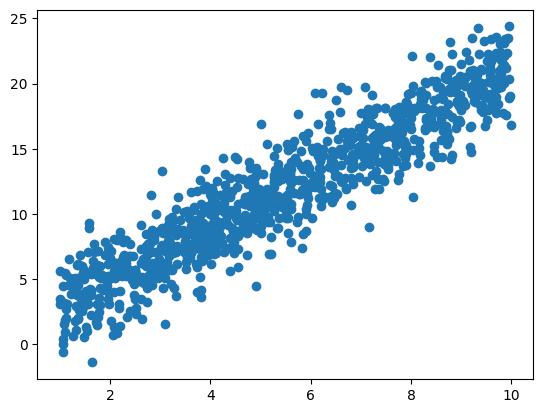

In [17]:
n_samples = 1000
data = np.random.uniform(1, 10, (n_samples, 1)).astype(np.float32)
targets = 2 * data + 1 + np.random.normal(0, 2, (n_samples, 1)).astype(np.float32)

plt.scatter(data, targets)
plt.show()

Создаем тензоры PyTorch:

In [18]:
data = torch.from_numpy(data)
targets = torch.from_numpy(targets)

Построим однослойную сеть, состоящую из одного нейрона, которая аналогична обычной линейной регрессии.

In [40]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.regr = nn.Linear(1, 1)

    def forward(self, x):
        y = self.regr(x)
        return y

In [41]:
model = NeuralNetwork()

Нарисуем предсказание модели со случайно инициализированными весами:

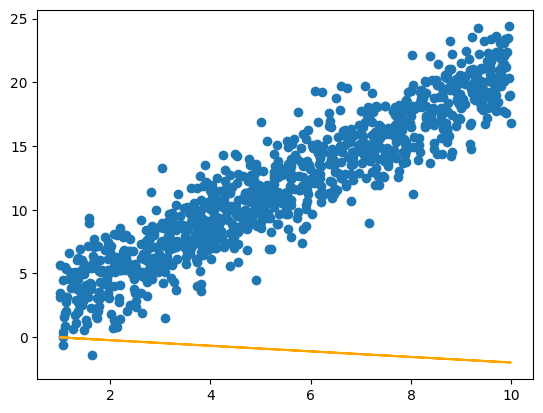

In [42]:
predictions = model(data)
plt.scatter(data.cpu().numpy(), targets.cpu().numpy())
plt.plot(data.cpu().detach().numpy(), predictions.cpu().detach().numpy(), color="orange")
plt.show()

Обучим нейронную сеть. Задаем функцию потерь (MSE) и создаем оптимизатор.

In [43]:
loss_fn = nn.MSELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Зададим функцию для обучения на одной эпохе, вычисляя `loss` отдельно на каждом примере.

In [45]:
def train_loop(data, targets, model, loss_fn, optimizer):
    model.train()
    for i in range(len(data)):
      optimizer.zero_grad()
      pred = model(data[i])
      loss = loss_fn(pred, targets[i])
      loss.backward()
      optimizer.step()
      if i % 100 == 0:
        print(f'loss: {loss}')

Запускаем цикл обучения:

In [ ]:
epochs = 10
for t in range(epochs):
    print(f'-------------------------------\nEpoch {t+1}')
    train_loop(data, targets, model, loss_fn, optimizer)

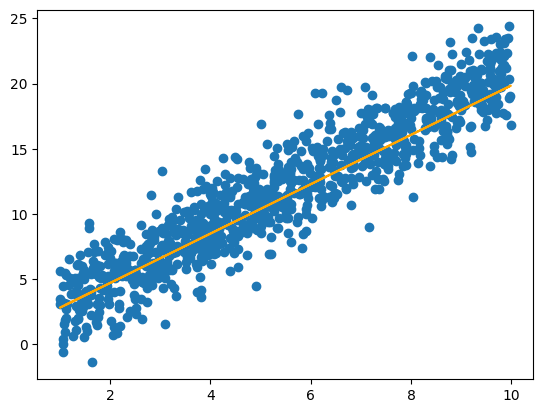

In [47]:
model.eval()
predictions = model(data)
plt.scatter(data.cpu().numpy(), targets.cpu().numpy())
plt.plot(data.cpu().detach().numpy(), predictions.cpu().detach().numpy(), color="orange")

## Задание 5
Обучите аналогично новую модель на прежних данных с помощью следующей функции обучения на одной эпохе.
```python
def train_loop2(data, targets, model, loss_fn, optimizer):
  model.train()
  optimizer.zero_grad()
  pred = model(data)
  loss = loss_fn(pred, targets)
  loss.backward()
  optimizer.step()
  print(f'loss: {loss}')
  ```
Сравните выводимые значения `loss` со значениями при обучении с помощью функции `train_loop()`. Письменно сформулируйте объяснения различий в логах и как это отражается на конечном результате?  
**Обратите внимание**, что при перезапуске блока с кодом обучения модели происходит продолжение обучения модели. Для нового обучения требуется пересоздавать соответствующие экземпляры.

In [ ]:
#ВАШ КОД И ОТВЕТ

## Задание 6
Разделите датасет на обучающую и валидационную выборки. Напишите функцию обучения, в которой в конце каждой эпохи вычисляется функция потерь на валидационной выборке без изменения весов модели. Постройте на одном графике значения `train_loss` и `val_loss` при обучении на 10 эпохах модели. Сделайте выводы.

In [ ]:
#ВАШ КОД И ОТВЕТ

## Задание 7
Исследуйте влияние значения `leaning_rate` при обучении модели на данной задаче (не забудьте инициализировать модель и соответственно оптимизатор для каждого нового значения `leaning_rate`). Постройте графики обучения на 10 эпохах при разном `leaning_rate`=[0.1, 0.01, 0.001, 0.0001]. На графиках покажите значения `train_loss` и `val_loss` при разных `leaning_rate`. Сделайте выводы.

In [31]:
#ВАШ КОД И ОТВЕТ

## Линейная классификация

Сгенерируем набор данных для классификации: объекты с меткой `0` будут нормально распределены вокруг точки (-1, -1),  объекты с меткой `1` – вокруг точки (1, 1):

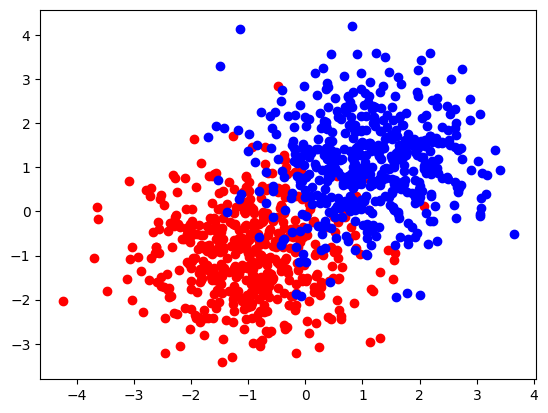

In [3]:
n_samples = 1000
half = int(n_samples / 2)
x_class0 = np.random.normal(size=[half, 2]) + [-1, -1]
y_class0 = np.zeros((half, 1))
x_class1 = np.random.normal(size=[half, 2]) + [1, 1]
y_class1 = np.ones((half, 1))
data = np.vstack([x_class0, x_class1])
targets = np.vstack([y_class0, y_class1])

data = data.astype(np.float32)
targets = targets.astype(np.float32)

plt.scatter(x_class0[:, 0], x_class0[:, 1], c='red')
plt.scatter(x_class1[:, 0], x_class1[:, 1], c='blue')

## Задание 8
Разбейте набор данных на обучающую и валидацинную выборки. Визуализируйте полученные выборки данных.  
Постройте нейронную сеть – линейный классификатор. Обучите нейронную сеть на 20 эпохах, используя оптимизатор torch.optim.SGD (значения гипрпараметров используйте по-умолчанию). Построите график значений `train_loss` и `val_loss`, а на отдельной диаграмме график значений `val_accuracy` на каждой эпохе. Сделайте выводы о ходе обучения модели.  
В качестве функции потерь можно использовать Binary Cross Entropy - ссылки на руководства https://docs.pytorch.org/docs/stable/generated/torch.nn.BCELoss.html и https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html.


In [ ]:
#ВАШ КОД И ОТВЕТ